# Persistence Model (Baseline) — Predicción de Tráfico M30
> Modelo de persistencia: la predicción para el instante `t+h` es el valor real observado en `t`.
> Se usa como **baseline de referencia** para comparar la ganancia de los modelos más complejos.
>
> **Configuraciones evaluadas:** lag=1h (h-1), lag=24h (mismo instante del día anterior), lag=168h (misma hora de la semana anterior).
>
> **Estilos:** Ver `documents/Estilos tfm.MD`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# CARGA DE DATOS — splits cronológicos (sin solapamiento)
# ---------------------------------------------------------------------------
ruta_train = '../../data/processed/Split_Datasets/data_train_clean.csv'
ruta_val   = '../../data/processed/Split_Datasets/data_val_clean.csv'
ruta_test  = '../../data/processed/Split_Datasets/data_test_clean.csv'

def preparar_indice_temporal(df):
    """Convierte 'fecha' en índice datetime con frecuencia horaria estricta."""
    df['fecha'] = pd.to_datetime(df['fecha'])
    df.set_index('fecha', inplace=True)
    df.sort_index(inplace=True)
    df = df.asfreq('h')
    return df

df_train = pd.read_csv(ruta_train, parse_dates=['fecha'], index_col='fecha')
df_val   = pd.read_csv(ruta_val,   parse_dates=['fecha'], index_col='fecha')
df_test  = pd.read_csv(ruta_test,  parse_dates=['fecha'], index_col='fecha')

df_train.sort_index(inplace=True)
df_val.sort_index(inplace=True)
df_test.sort_index(inplace=True)

# ---------------------------------------------------------------------------
# Definición de columnas
# ---------------------------------------------------------------------------
cols_endogenas  = [col for col in df_train.columns
                   if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col]
cols_exogenas   = ['hora', 'dia_semana', 'mes', 'es_finde']
cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]
sensores        = ['Sensor 3820', 'Sensor 6642', 'Sensor 6676', 'Sensor 6782']
sensor_ids      = ['3820', '6642', '6676', '6782']

print("--- ESTRUCTURA DE DATOS ---")
print(f"Train : {df_train.shape} | {df_train.index.min()} → {df_train.index.max()}")
print(f"Val   : {df_val.shape}   | {df_val.index.min()} → {df_val.index.max()}")
print(f"Test  : {df_test.shape}  | {df_test.index.min()} → {df_test.index.max()}")
print(f"\nVariables objetivo (intensidad): {cols_intensidad}")


--- ESTRUCTURA DE DATOS ---
Train : (16080, 16) | 2024-01-01 00:00:00 → 2025-10-31 23:00:00
Val   : (1464, 16)   | 2025-11-01 00:00:00 → 2025-12-31 23:00:00
Test  : (1416, 16)  | 2026-01-01 00:00:00 → 2026-02-28 23:00:00

Variables objetivo (intensidad): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782']


## 2. Imputación y Variables de Calendario

In [2]:
def limpiar_nulos(df, cols_endo):
    """Imputa nulos por interpolación lineal y reconstruye variables de calendario."""
    df[cols_endo] = df[cols_endo].interpolate(method='linear', limit_direction='both')
    df['hora']       = df.index.hour
    df['dia_semana'] = df.index.dayofweek
    df['mes']        = df.index.month
    df['es_finde']   = (df['dia_semana'] >= 5).astype(int)
    return df

df_train = limpiar_nulos(df_train, cols_endogenas)
df_val   = limpiar_nulos(df_val,   cols_endogenas)
df_test  = limpiar_nulos(df_test,  cols_endogenas)

nulos_total = (df_train.isnull().sum().sum() +
               df_val.isnull().sum().sum()   +
               df_test.isnull().sum().sum())
print(f"✅ Nulos totales tras imputación: {nulos_total}")


✅ Nulos totales tras imputación: 0


## 3. Función del Modelo de Persistencia

El modelo de persistencia predice el valor futuro usando el valor pasado a un lag fijo:
```
y_pred(t+h) = y_real(t)
```
No requiere entrenamiento; es un modelo determinista basado en la repetición del patrón.

In [3]:
def predecir_persistencia(df, cols_target, lag):
    """
    Modelo de persistencia: pred(t) = real(t - lag).
    
    Parámetros
    ----------
    df          : DataFrame con índice temporal (test o val)
    cols_target : columnas de intensidad a predecir
    lag         : número de horas de retardo (1, 24 ó 168)
    
    Retorna
    -------
    y_real : np.ndarray (n_muestras, n_sensores) — valores reales en t
    y_pred : np.ndarray (n_muestras, n_sensores) — valores reales en t-lag (predicción)
    index  : índice temporal de los instantes predichos
    """
    # Alineamos real(t) con pred = real(t-lag)
    y_real = df[cols_target].iloc[lag:].values
    y_pred = df[cols_target].iloc[:-lag].values
    index  = df.index[lag:]
    return y_real, y_pred, index

# Configuraciones del modelo de persistencia a evaluar
lags_persistencia = [1, 24, 168]

print("--- PERSISTENCIA: DESCRIPCIÓN ---")
for lag in lags_persistencia:
    print(f"  Persistence-{lag}h : pred(t) = real(t - {lag})")
print()
print("Este modelo NO requiere entrenamiento.")
print("Se evalúa directamente sobre el conjunto TEST.")


--- PERSISTENCIA: DESCRIPCIÓN ---
  Persistence-1h : pred(t) = real(t - 1)
  Persistence-24h : pred(t) = real(t - 24)
  Persistence-168h : pred(t) = real(t - 168)

Este modelo NO requiere entrenamiento.
Se evalúa directamente sobre el conjunto TEST.


## 4. Evaluación sobre TEST — Tabla Resumen de Métricas

In [4]:
# ---------------------------------------------------------------------------
# 4. EVALUACIÓN SOBRE TEST — Tabla Resumen de Métricas (Corregido)
# ---------------------------------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calcular_metricas_robustas(y_real, y_pred):
    """Calcula RMSE, MAE y R² para cada sensor SIEMPRE, sin restricciones."""
    resultados = {}
    for j, sensor in enumerate(sensores):
        real_j = y_real[:, j]
        pred_j = y_pred[:, j]
        
        mask = ~np.isnan(real_j) & ~np.isnan(pred_j)
        
        rmse = np.sqrt(mean_squared_error(real_j[mask], pred_j[mask]))
        mae  = mean_absolute_error(real_j[mask], pred_j[mask])
        
        # Eliminamos la restricción. Ahora siempre calcula el R²
        r2   = r2_score(real_j[mask], pred_j[mask])
        
        resultados[sensor] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    return resultados

print("--- EVALUACIÓN PERSISTENCE SOBRE TEST ---")
resultados_test = {}

# Evaluamos directamente con los arrays desplazados
for lag in lags_persistencia:
    y_real, y_pred, idx = predecir_persistencia(df_test, cols_intensidad, lag)
    
    metricas = calcular_metricas_robustas(y_real, y_pred)
    resultados_test[(lag, lag)] = metricas
    print(f"  ✅ Persistence-{lag}h evaluado sobre test. Puntos: {len(y_real)}")

# Tabla de resultados
print()
for lag in lags_persistencia:
    print(f"\n{'='*60}")
    print(f"  PERSISTENCE-{lag}h — RESULTADOS SOBRE TEST")
    print(f"{'='*60}")
    print(f"  (Pred(t) = Real(t-{lag}))")
    print(f"  {'Sensor':<14} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
    print(f"  {'-'*44}")
    rmse_vals, mae_vals, r2_vals = [], [], []
    
    for sensor in sensores:
        m = resultados_test[(lag, lag)][sensor]
        print(f"  {sensor:<14} {m['RMSE']:>10.2f} {m['MAE']:>10.2f} {m['R²']:>10.4f}")
        rmse_vals.append(m['RMSE'])
        mae_vals.append(m['MAE'])
        r2_vals.append(m['R²'])
        
    print(f"  {'-'*44}")
    print(f"  {'PROMEDIO':<14} {sum(rmse_vals)/len(rmse_vals):>10.2f} {sum(mae_vals)/len(mae_vals):>10.2f} {sum(r2_vals)/len(r2_vals):>10.4f}")

--- EVALUACIÓN PERSISTENCE SOBRE TEST ---
  ✅ Persistence-1h evaluado sobre test. Puntos: 1415
  ✅ Persistence-24h evaluado sobre test. Puntos: 1392
  ✅ Persistence-168h evaluado sobre test. Puntos: 1248


  PERSISTENCE-1h — RESULTADOS SOBRE TEST
  (Pred(t) = Real(t-1))
  Sensor               RMSE        MAE         R²
  --------------------------------------------
  Sensor 3820        753.69     537.51     0.8373
  Sensor 6642        884.77     623.01     0.8276
  Sensor 6676        776.61     571.99     0.8205
  Sensor 6782        776.46     569.22     0.8047
  --------------------------------------------
  PROMEDIO           797.88     575.43     0.8225

  PERSISTENCE-24h — RESULTADOS SOBRE TEST
  (Pred(t) = Real(t-24))
  Sensor               RMSE        MAE         R²
  --------------------------------------------
  Sensor 3820        920.11     592.71     0.7585
  Sensor 6642       1075.48     591.03     0.7468
  Sensor 6676        870.44     539.99     0.7756
  Sensor 6782       

## 5. Gráficas — Semana 2-8 febrero 2026 (Estilos TFM)

Se comparan dos configuraciones de persistencia: lag=48h y lag=168h.

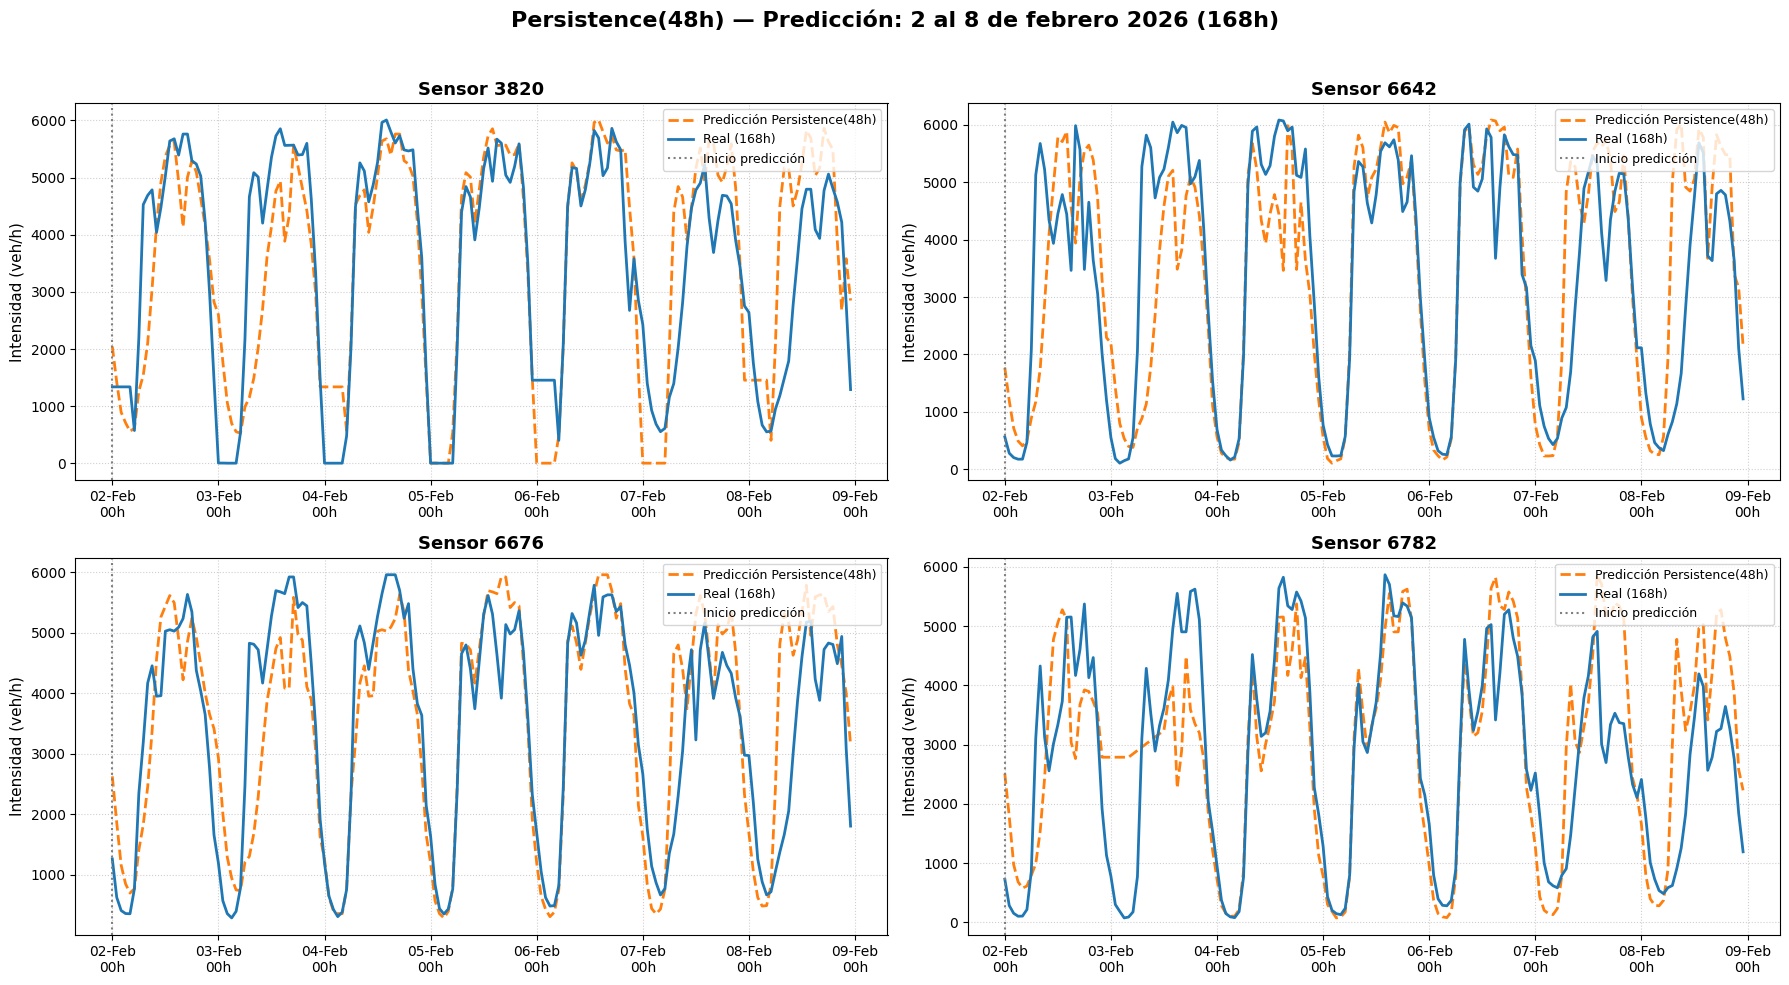

✅ Gráfica generada: Persistence(48h)


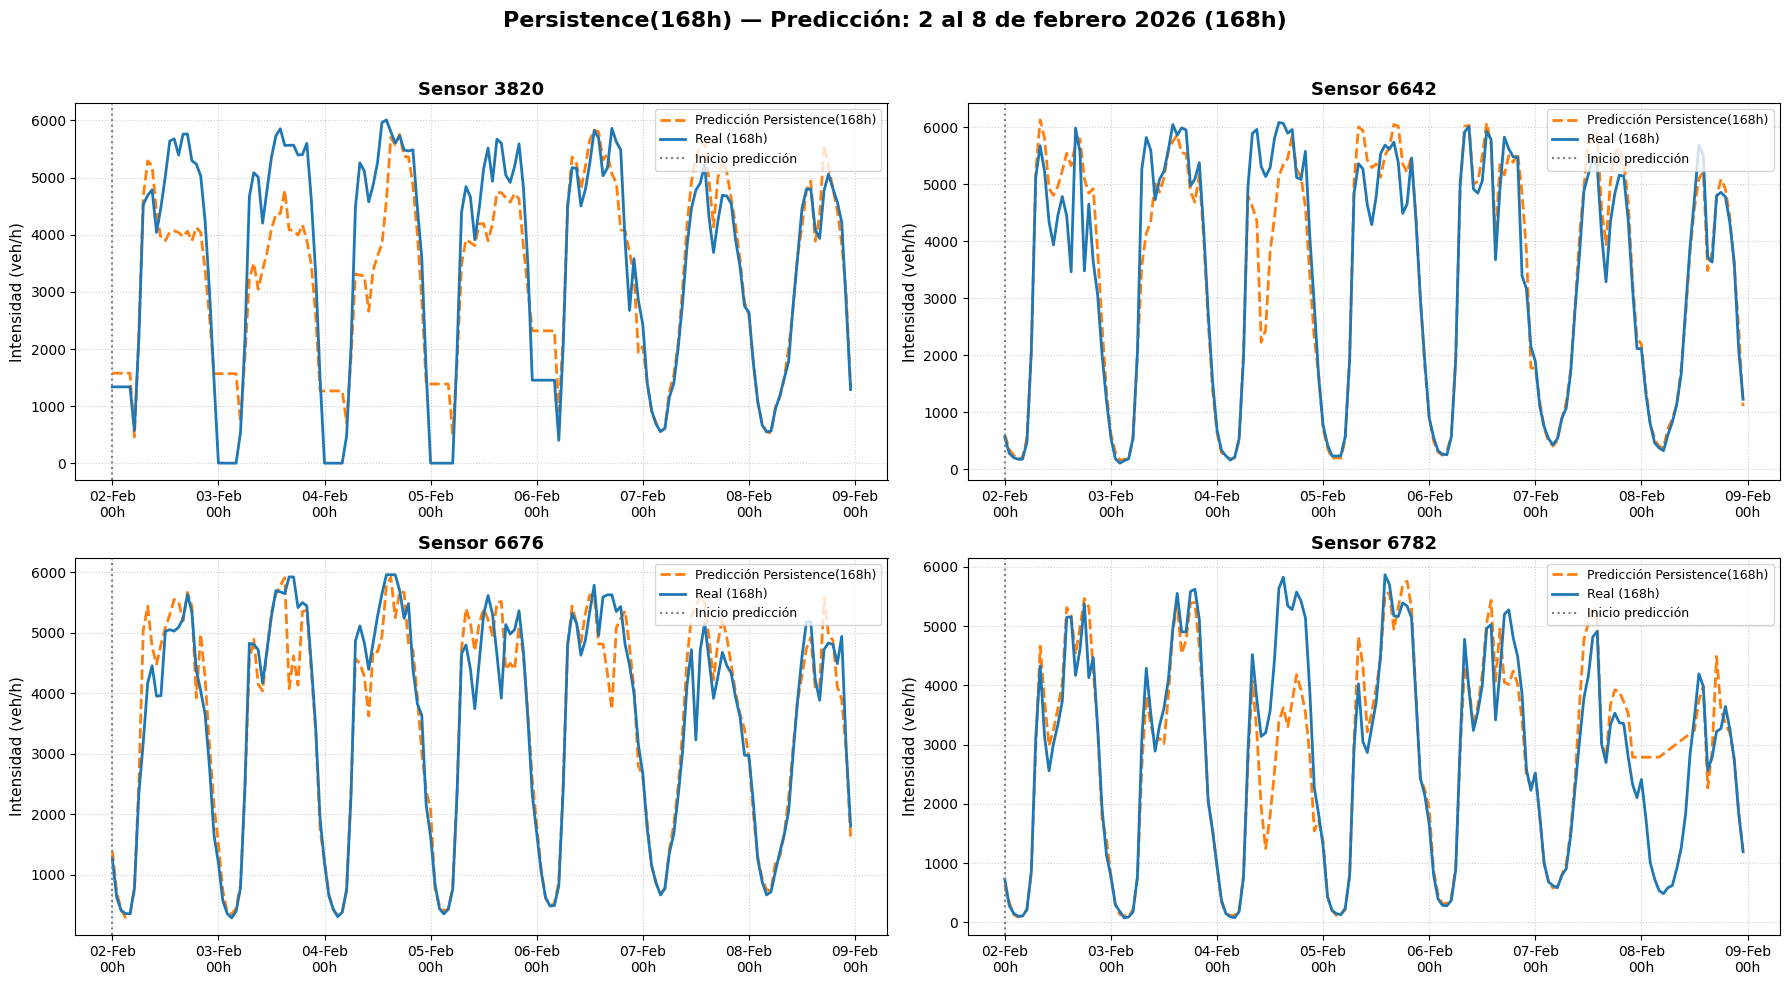

✅ Gráfica generada: Persistence(168h)


In [5]:
semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
semana_fin    = pd.Timestamp('2026-02-08 23:00:00')
real_semana   = df_test.loc[semana_inicio:semana_fin, cols_intensidad]

# Predicción persistencia-48h para la semana
seg_48_inicio  = semana_inicio - pd.Timedelta(hours=48)
seg_168_inicio = semana_inicio - pd.Timedelta(hours=168)

pred_semana_48  = df_test.loc[seg_48_inicio  : semana_fin - pd.Timedelta(hours=48),  cols_intensidad].copy()
pred_semana_168 = df_test.loc[seg_168_inicio : semana_fin - pd.Timedelta(hours=168), cols_intensidad].copy()

# Re-indexar para alinear con la semana real
pred_semana_48.index  = pred_semana_48.index  + pd.Timedelta(hours=48)
pred_semana_168.index = pred_semana_168.index + pd.Timedelta(hours=168)

# Filtrar al rango exacto de la semana
pred_semana_48  = pred_semana_48.loc[semana_inicio:semana_fin]
pred_semana_168 = pred_semana_168.loc[semana_inicio:semana_fin]

# Graficar con función estándar TFM
for lag, pred_semana, nombre_lag in [(48, pred_semana_48, '48'), (168, pred_semana_168, '168')]:
    nombre_modelo = f'Persistence({nombre_lag}h)'
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
    fig.suptitle(
        f'{nombre_modelo} — Predicción: 2 al 8 de febrero 2026 (168h)',
        fontsize=16, fontweight='bold', y=0.98
    )
    axes = axes.flatten()
    for i, col in enumerate(cols_intensidad):
        ax        = axes[i]
        sensor_id = sensor_ids[i]
        ax.plot(pred_semana.index, pred_semana[col],
                color='#ff7f0e', linewidth=2, linestyle='--',
                label=f'Predicción {nombre_modelo}')
        ax.plot(real_semana.index, real_semana[col],
                color='#1f77b4', linewidth=2, label='Real (168h)')
        ax.axvline(x=semana_inicio, color='grey', linestyle=':',
                   linewidth=1.5, label='Inicio predicción')
        ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
        ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%Hh'))
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
        ax.tick_params(axis='x', rotation=0)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    print(f"✅ Gráfica generada: {nombre_modelo}")


## 6. Exportación Excel — Persistence-48h vs Persistence-168h

In [6]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import os

def exportar_excel(resultados_test, nombre_modelo_base, color_48, color_168, ruta_excel):
    """Exporta el Excel comparativo 48h vs 168h según Estilos TFM."""
    os.makedirs(os.path.dirname(ruta_excel), exist_ok=True)
    
    horizontes_nombres = {1: '1_HORA', 24: '24_HORAS', 168: '168_HORAS'}
    horizontes_titulos = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}
    
    def estilo_titulo(ws, fila, texto):
        ws.merge_cells(start_row=fila, start_column=1, end_row=fila, end_column=7)
        c = ws.cell(row=fila, column=1, value=texto)
        c.font      = Font(bold=True, color='FFFFFF', size=12)
        c.fill      = PatternFill('solid', fgColor='2F4F8F')
        c.alignment = Alignment(horizontal='center', vertical='center')

    def aplicar_borde(cell):
        thin = Side(style='thin')
        cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

    wb = openpyxl.Workbook()
    wb.remove(wb.active)

    for horizonte in [1, 24, 168]:
        nombre_hoja = horizontes_nombres[horizonte]
        titulo_hoja = horizontes_titulos[horizonte]
        ws = wb.create_sheet(title=nombre_hoja)

        anchos = [16, 12, 12, 12, 12, 12, 12]
        for i, ancho in enumerate(anchos, 1):
            ws.column_dimensions[openpyxl.utils.get_column_letter(i)].width = ancho

        estilo_titulo(ws, 1, f'HORIZONTE: {titulo_hoja} — {nombre_modelo_base}-48h vs {nombre_modelo_base}-168h')
        ws.row_dimensions[1].height = 22

        ws.merge_cells(start_row=2, start_column=2, end_row=2, end_column=4)
        ws.merge_cells(start_row=2, start_column=5, end_row=2, end_column=7)
        for col, texto, color in [(2, f'{nombre_modelo_base}-48h', color_48),
                                   (5, f'{nombre_modelo_base}-168h', color_168)]:
            c = ws.cell(row=2, column=col, value=texto)
            c.font      = Font(bold=True, color='FFFFFF', size=10)
            c.fill      = PatternFill('solid', fgColor=color)
            c.alignment = Alignment(horizontal='center', vertical='center')

        ws.cell(row=3, column=1, value='Sensor').font = Font(bold=True, color='FFFFFF', size=10)
        ws.cell(row=3, column=1).fill                 = PatternFill('solid', fgColor='4472C4')
        ws.cell(row=3, column=1).alignment            = Alignment(horizontal='center')
        for col, metrica in enumerate(['RMSE', 'MAE', 'R²', 'RMSE', 'MAE', 'R²'], 2):
            c = ws.cell(row=3, column=col, value=metrica)
            c.font      = Font(bold=True, color='FFFFFF', size=10)
            c.fill      = PatternFill('solid', fgColor='4472C4')
            c.alignment = Alignment(horizontal='center')

        colores_fila = ['FCE4D6', 'E2EFDA', 'FCE4D6', 'E2EFDA']
        for idx, sensor in enumerate(sensores):
            fila  = 4 + idx
            color = colores_fila[idx]
            m48   = resultados_test[(48,  horizonte)][sensor]
            m168  = resultados_test[(168, horizonte)][sensor]
            
            def fmt_r2(val):
                return round(val, 4) if val is not None else 'N/A'
            
            valores = [sensor,
                       round(m48['RMSE'], 2),  round(m48['MAE'], 2),  fmt_r2(m48['R²']),
                       round(m168['RMSE'], 2), round(m168['MAE'], 2), fmt_r2(m168['R²'])]
            for col, val in enumerate(valores, 1):
                c = ws.cell(row=fila, column=col, value=val)
                c.fill      = PatternFill('solid', fgColor=color)
                c.font      = Font(size=10)
                c.alignment = Alignment(horizontal='center')
                aplicar_borde(c)

        fila_prom = 8
        ws.cell(row=fila_prom, column=1, value='PROMEDIO')
        
        def prom_r2(lag, h):
            vals = [resultados_test[(lag, h)][s]['R²'] for s in sensores if resultados_test[(lag, h)][s]['R²'] is not None]
            return round(sum(vals)/len(vals), 4) if vals else 'N/A'
        
        promedios = [
            round(np.mean([resultados_test[(48,  horizonte)][s]['RMSE'] for s in sensores]), 2),
            round(np.mean([resultados_test[(48,  horizonte)][s]['MAE']  for s in sensores]), 2),
            prom_r2(48, horizonte),
            round(np.mean([resultados_test[(168, horizonte)][s]['RMSE'] for s in sensores]), 2),
            round(np.mean([resultados_test[(168, horizonte)][s]['MAE']  for s in sensores]), 2),
            prom_r2(168, horizonte),
        ]
        for col, val in enumerate([None] + promedios, 1):
            c = ws.cell(row=fila_prom, column=col)
            if col > 1:
                c.value = val
            c.font      = Font(bold=True, size=10)
            c.fill      = PatternFill('solid', fgColor='D9E1F2')
            c.alignment = Alignment(horizontal='center')
            aplicar_borde(c)

    wb.save(ruta_excel)
    print(f"✅ Excel guardado en: {ruta_excel}")


In [7]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import os

os.makedirs('../../data/processed/models/0.Persistence', exist_ok=True)
ruta_excel = '../../data/processed/models/0.Persistence/comparativa_Persistence48_vs_Persistence168_v02.xlsx'

horizontes_nombres = {1: '1_HORA', 24: '24_HORAS', 168: '168_HORAS'}
horizontes_titulos = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}

def estilo_titulo(ws, fila, texto):
    ws.merge_cells(start_row=fila, start_column=1, end_row=fila, end_column=7)
    c = ws.cell(row=fila, column=1, value=texto)
    c.font      = Font(bold=True, color='FFFFFF', size=12)
    c.fill      = PatternFill('solid', fgColor='2F4F8F')
    c.alignment = Alignment(horizontal='center', vertical='center')

def aplicar_borde(cell):
    thin = Side(style='thin')
    cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = openpyxl.Workbook()
wb.remove(wb.active)

# Para Persistence usamos una estructura especial:
# Persistence-1h | Persistence-24h | Persistence-168h en columnas
for idx_lag, lag_pers in enumerate(lags_persistencia):
    nombre_hoja = f'Persistence_{lag_pers}h'
    ws = wb.create_sheet(title=nombre_hoja)
    anchos = [16, 12, 12, 12]
    for i, ancho in enumerate(anchos, 1):
        ws.column_dimensions[openpyxl.utils.get_column_letter(i)].width = ancho
    
    # Título
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=4)
    c = ws.cell(row=1, column=1, value=f'PERSISTENCE-{lag_pers}h — pred(t) = real(t-{lag_pers})')
    c.font = Font(bold=True, color='FFFFFF', size=12)
    c.fill = PatternFill('solid', fgColor='2F4F8F')
    c.alignment = Alignment(horizontal='center', vertical='center')
    ws.row_dimensions[1].height = 22
    
    # Cabecera
    colores_header = ['4D4D4D', '4472C4', '4472C4', '4472C4']
    headers = ['Sensor', 'RMSE', 'MAE', 'R²']
    for col, (hdr, color) in enumerate(zip(headers, colores_header), 1):
        c = ws.cell(row=2, column=col, value=hdr)
        c.font = Font(bold=True, color='FFFFFF', size=10)
        c.fill = PatternFill('solid', fgColor=color)
        c.alignment = Alignment(horizontal='center')
    
    # Datos
    colores_fila = ['FCE4D6', 'E2EFDA', 'FCE4D6', 'E2EFDA']
    for idx_s, sensor in enumerate(sensores):
        fila = 3 + idx_s
        m = resultados_test[(lag_pers, lag_pers)][sensor]
        r2_val = round(m['R²'], 4) if m['R²'] is not None else 'N/A'
        valores = [sensor, round(m['RMSE'], 2), round(m['MAE'], 2), r2_val]
        for col, val in enumerate(valores, 1):
            c = ws.cell(row=fila, column=col, value=val)
            c.fill = PatternFill('solid', fgColor=colores_fila[idx_s])
            c.font = Font(size=10)
            c.alignment = Alignment(horizontal='center')
            aplicar_borde(c)
    
    # Promedio
    fila_prom = 7
    rmse_vals = [resultados_test[(lag_pers, lag_pers)][s]['RMSE'] for s in sensores]
    mae_vals  = [resultados_test[(lag_pers, lag_pers)][s]['MAE']  for s in sensores]
    r2_vals   = [resultados_test[(lag_pers, lag_pers)][s]['R²']   for s in sensores if resultados_test[(lag_pers, lag_pers)][s]['R²'] is not None]
    r2_prom   = round(sum(r2_vals)/len(r2_vals), 4) if r2_vals else 'N/A'
    promedios = ['PROMEDIO', round(np.mean(rmse_vals), 2), round(np.mean(mae_vals), 2), r2_prom]
    for col, val in enumerate(promedios, 1):
        c = ws.cell(row=fila_prom, column=col, value=val)
        c.font = Font(bold=True, size=10)
        c.fill = PatternFill('solid', fgColor='D9E1F2')
        c.alignment = Alignment(horizontal='center')
        aplicar_borde(c)

wb.save(ruta_excel)
print(f"✅ Excel guardado en: {ruta_excel}")


✅ Excel guardado en: ../../data/processed/models/0.Persistence/comparativa_Persistence48_vs_Persistence168_v02.xlsx
